In [32]:
from utils import load_raw_data   # import the raw (uncleaned) loader specifically
from utils import load_clean_data

import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
import matplotlib.pyplot as plt

In [33]:
df = load_raw_data("data.csv")

In [34]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Shape: 80765 rows, 18 columns


In [35]:
df.head()

,training_date,id,reg_year,plate_age_id,year_plate_start_date,mileage,advertised_price,at_derivative_id,make,model,generation,fuel,engine,body,transmission,trim,doors,list_price
0,2023-06-01,e79c9066f50e136b5ab14bb39996a62b,2009,9,2009-03-01,83000,5290,ff04b6482e3e4eaf9af497526d99f874,Mercedes-Benz,SLK,Convertible (2008 - 2011),Petrol,1.80,Convertible,Automatic,NaN,2,"31,986.00"
1,2023-06-01,3314e91aaa6e5d8adfec7266ae7f9ece,2009,9,2009-03-01,85900,9500,cb37d7493efd45b4a172b20258b3d323,BMW,X5,SUV (2006 - 2014),Diesel,3.00,SUV,Automatic,M Sport,5,"48,444.00"
2,2023-06-01,36350752d23f19eb8eb3d3f545b2633f,2009,9,2009-03-01,114000,4490,85e0026201a141d4b68d07dfd1fe2141,Volvo,XC70,Estate (2007 - 2013) MK 2,Diesel,2.40,Estate,Manual,SE,5,"30,146.00"
3,2023-06-01,dada9107064ba35a5570b939d2861f97,2009,9,2009-03-01,24900,3829,8f1339f38bab4f0aa8f194963e38e905,Suzuki,Alto,Hatchback (2009 - 2015) MK 6,Petrol,1.00,Hatchback,Manual,SZ3,5,"7,891.00"
4,2023-06-01,32d056600b4346d9ddd96775fb6cf926,2009,9,2009-03-01,99000,2995,22be473a397e4641a3ba52ea1d4be819,Mazda,Mazda3,Hatchback (2009 - 2013),Petrol,1.60,Hatchback,Manual,Sport,5,"17,370.00"


In [36]:
df.dtypes

training_date                str
id                           str
reg_year                   int64
plate_age_id               int64
year_plate_start_date        str
mileage                    int64
advertised_price           int64
at_derivative_id             str
make                         str
model                        str
generation                   str
fuel                         str
engine                   float64
body                         str
transmission                 str
trim                         str
doors                      int64
list_price               float64
dtype: object

In [37]:
# Count missing values per column
missing = df.isnull().sum()

# Convert to percentage of total rows, easier to judge severity at a glance
missing_pct = (missing / len(df)) * 100

# Combine into one table, sorted worst-first
missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct.round(2)
}).sort_values("missing_pct", ascending=False)

missing_summary

,missing_count,missing_pct
engine,3281,4.06
trim,2521,3.12
id,0,0.00
training_date,0,0.00
reg_year,0,0.00
plate_age_id,0,0.00
advertised_price,0,0.00
at_derivative_id,0,0.00
year_plate_start_date,0,0.00
mileage,0,0.00


In [38]:
# List the categorical columns we'll eventually need to encode
categorical_cols = ["make", "model", "generation", "fuel", "engine", 
                     "body", "transmission", "trim", "plate_age_id", 
                     "at_derivative_id"]

# Print the number of DISTINCT values per categorical column
# This tells us cardinality — directly affects which encoders are viable per column
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

make: 63 unique values
model: 676 unique values
generation: 841 unique values
fuel: 8 unique values
engine: 54 unique values
body: 7 unique values
transmission: 2 unique values
trim: 1520 unique values
plate_age_id: 30 unique values
at_derivative_id: 19841 unique values


In [39]:
# For each categorical column, print the 15 most frequent values
# Helps spot inconsistent formatting (e.g. "Automatic" vs "automatic")
# or placeholder values hiding as a category (e.g. "Unknown", "-")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(15))


--- make ---
make
Ford             7426
Audi             6806
BMW              6614
Volkswagen       6522
Mercedes-Benz    6190
Vauxhall         4999
Land Rover       3489
Toyota           3426
Nissan           3324
Kia              2977
Peugeot          2826
Hyundai          2398
MINI             2346
SKODA            2147
Volvo            1991
Name: count, dtype: int64

--- model ---
model
Fiesta      2538
Golf        2254
Focus       1897
Corsa       1594
A Class     1591
1 Series    1312
C Class     1293
3 Series    1290
Hatch       1263
Qashqai     1205
A3          1078
Polo        1035
500         1000
Juke         961
Sportage     957
Name: count, dtype: int64

--- generation ---
generation
SUV (2019 - )              3368
SUV (2017 - 2021)          2762
Hatchback (2019 - )        2252
Hatchback (2017 - 2020)    2219
Hatchback (2017 - 2021)    2150
SUV (2020 - )              2097
Hatchback (2020 - )        1992
SUV (2016 - 2020)          1883
SUV (2018 - )              1862
Hatc

In [40]:
# Specifically check whether "engine" is missing ONLY for electric vehicles
# (as the schema suggested — engine size isn't applicable to EVs)
# This confirms whether the missingness is structural/explainable rather than random
df.groupby("fuel")["engine"].apply(lambda x: x.isnull().sum())

fuel
Bi Fuel                     0
Diesel                      0
Diesel Hybrid               0
Diesel Plug-in Hybrid       0
Electric                 3220
Petrol                      0
Petrol Hybrid               0
Petrol Plug-in Hybrid      61
Name: engine, dtype: int64

In [41]:
# Summary statistics for the target variable (advertised_price)
# Useful for spotting obvious data errors (e.g. price of £0, or extreme outliers)
df["advertised_price"].describe()

count      80,765.00
mean       21,270.82
std        22,805.72
min           695.00
25%        10,495.00
50%        16,990.00
75%        24,499.00
max     1,195,000.00
Name: advertised_price, dtype: float64

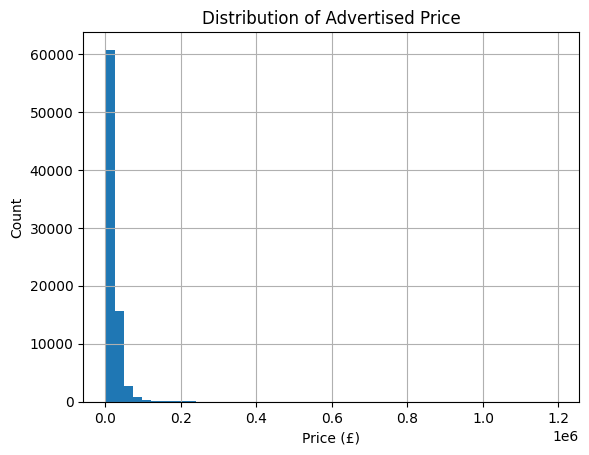

In [42]:
# Visualise the distribution of advertised_price
df["advertised_price"].hist(bins=50)
plt.title("Distribution of Advertised Price")
plt.xlabel("Price (£)")
plt.ylabel("Count")
plt.show()

In [43]:
df_raw = load_raw_data("data.csv")
df_clean = load_clean_data("data.csv")

print(f"Raw shape: {df_raw.shape}")
print(f"Clean shape: {df_clean.shape}")
print(f"Rows removed: {df_raw.shape[0] - df_clean.shape[0]}")

Raw shape: (80765, 18)
Clean shape: (79162, 17)
Rows removed: 1603


In [44]:
df_raw.head()

,training_date,id,reg_year,plate_age_id,year_plate_start_date,mileage,advertised_price,at_derivative_id,make,model,generation,fuel,engine,body,transmission,trim,doors,list_price
0,2023-06-01,e79c9066f50e136b5ab14bb39996a62b,2009,9,2009-03-01,83000,5290,ff04b6482e3e4eaf9af497526d99f874,Mercedes-Benz,SLK,Convertible (2008 - 2011),Petrol,1.80,Convertible,Automatic,NaN,2,"31,986.00"
1,2023-06-01,3314e91aaa6e5d8adfec7266ae7f9ece,2009,9,2009-03-01,85900,9500,cb37d7493efd45b4a172b20258b3d323,BMW,X5,SUV (2006 - 2014),Diesel,3.00,SUV,Automatic,M Sport,5,"48,444.00"
2,2023-06-01,36350752d23f19eb8eb3d3f545b2633f,2009,9,2009-03-01,114000,4490,85e0026201a141d4b68d07dfd1fe2141,Volvo,XC70,Estate (2007 - 2013) MK 2,Diesel,2.40,Estate,Manual,SE,5,"30,146.00"
3,2023-06-01,dada9107064ba35a5570b939d2861f97,2009,9,2009-03-01,24900,3829,8f1339f38bab4f0aa8f194963e38e905,Suzuki,Alto,Hatchback (2009 - 2015) MK 6,Petrol,1.00,Hatchback,Manual,SZ3,5,"7,891.00"
4,2023-06-01,32d056600b4346d9ddd96775fb6cf926,2009,9,2009-03-01,99000,2995,22be473a397e4641a3ba52ea1d4be819,Mazda,Mazda3,Hatchback (2009 - 2013),Petrol,1.60,Hatchback,Manual,Sport,5,"17,370.00"


In [45]:
df_clean.head()

,reg_year,plate_age_id,mileage,advertised_price,make,model,generation,fuel,engine,body,transmission,trim,doors,list_price,vehicle_age_days,vehicle_age_years,engine_missing
0,2009,9,83000,5290,Mercedes-Benz,SLK,Convertible (2008 - 2011),Petrol,1.80,Convertible,Automatic,Missing,2,"31,986.00",5205,14.25,0
1,2009,9,85900,9500,BMW,X5,SUV (2006 - 2014),Diesel,3.00,SUV,Automatic,M Sport,5,"48,444.00",5205,14.25,0
2,2009,9,114000,4490,Volvo,XC70,Estate (2007 - 2013) MK 2,Diesel,2.40,Estate,Manual,SE,5,"30,146.00",5205,14.25,0
3,2009,9,24900,3829,Suzuki,Alto,Hatchback (2009 - 2015) MK 6,Petrol,1.00,Hatchback,Manual,SZ3,5,"7,891.00",5205,14.25,0
4,2009,9,99000,2995,Mazda,Mazda3,Hatchback (2009 - 2013),Petrol,1.60,Hatchback,Manual,Sport,5,"17,370.00",5205,14.25,0


In [46]:
df_clean.dtypes

reg_year               int64
plate_age_id           int64
mileage                int64
advertised_price       int64
make                     str
model                    str
generation               str
fuel                     str
engine               float64
body                     str
transmission             str
trim                     str
doors                  int64
list_price           float64
vehicle_age_days       int64
vehicle_age_years    float64
engine_missing         int64
dtype: object

In [47]:
df_clean.isnull().sum()

reg_year             0
plate_age_id         0
mileage              0
advertised_price     0
make                 0
model                0
generation           0
fuel                 0
engine               0
body                 0
transmission         0
trim                 0
doors                0
list_price           0
vehicle_age_days     0
vehicle_age_years    0
engine_missing       0
dtype: int64

In [48]:
# Re-check cardinality of categorical columns on the CLEANED data
# at_derivative_id should no longer appear (dropped), everything else
# should match what we saw in exploration (cleaning doesn't change
# cardinality of columns we didn't touch, this is just a confirmation)
categorical_cols = ["make", "model", "generation", "fuel", 
                     "body", "transmission", "trim", "plate_age_id"]

for col in categorical_cols:
    print(f"{col}: {df_clean[col].nunique()} unique values")

make: 61 unique values
model: 634 unique values
generation: 811 unique values
fuel: 8 unique values
body: 7 unique values
transmission: 2 unique values
trim: 1441 unique values
plate_age_id: 30 unique values


In [49]:
# Specifically verify the engine_missing flag worked correctly
# Every row where engine_missing == 1 should have engine == 0
# and should correspond to Electric or Petrol Plug-in Hybrid fuel types
df_clean[df_clean["engine_missing"] == 1]["fuel"].value_counts()

fuel
Electric                 3191
Petrol Plug-in Hybrid      61
Name: count, dtype: int64

In [50]:
# Verify trim missing values were correctly filled with "Missing"
# rather than left as NaN
df_clean["trim"].value_counts().head(10)  # "Missing" should now appear as a category

trim
SE               3995
M Sport          3526
Sport            3239
AMG Line         2965
S line           2474
Missing          2268
Zetec            1624
Titanium         1555
Black Edition    1184
S                1005
Name: count, dtype: int64

In [51]:
# Check the new vehicle_age_years column looks sensible
# (no negative ages, no absurdly large ages like 100+ years)
df_clean["vehicle_age_years"].describe()

count   79,162.00
mean         5.43
std          3.32
min          0.25
25%          3.25
50%          4.75
75%          7.75
max         14.75
Name: vehicle_age_years, dtype: float64

In [52]:
# Explicitly check for any negative ages
negative_age_count = (df_clean["vehicle_age_years"] < 0).sum()
print(f"Rows with negative vehicle age: {negative_age_count}")

Rows with negative vehicle age: 0


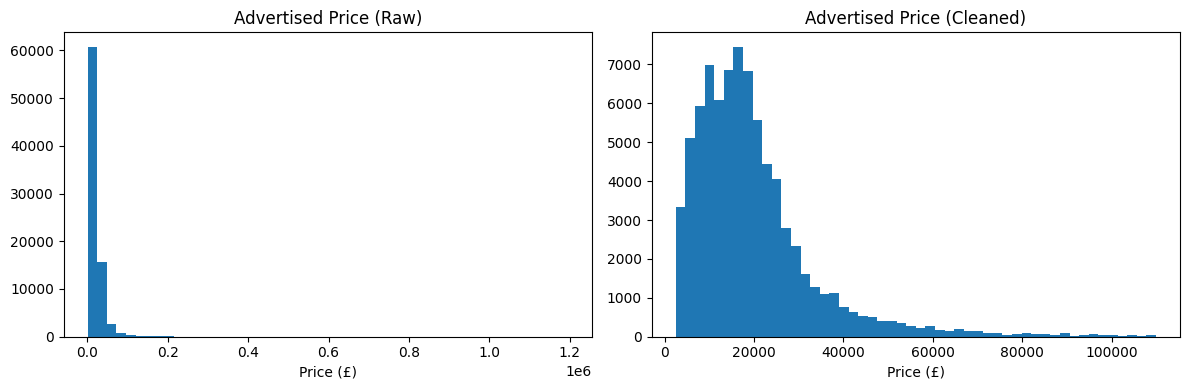

In [53]:
# Compare advertised_price distribution BEFORE and AFTER outlier removal
# This visually confirms the 1st/99th percentile trimming worked as intended

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw price distribution (includes the extreme outliers, e.g. the £1.195m listing)
axes[0].hist(df_raw['advertised_price'], bins=50)
axes[0].set_title('Advertised Price (Raw)')
axes[0].set_xlabel('Price (£)')

# Clean price distribution (outliers trimmed)
axes[1].hist(df_clean['advertised_price'], bins=50)
axes[1].set_title('Advertised Price (Cleaned)')
axes[1].set_xlabel('Price (£)')

plt.tight_layout()
plt.show()

In [54]:
# Compare summary statistics before and after outlier removal
print("RAW price stats:")
print(df_raw['advertised_price'].describe())
print("\nCLEAN price stats:")
print(df_clean['advertised_price'].describe())

RAW price stats:
count      80,765.00
mean       21,270.82
std        22,805.72
min           695.00
25%        10,495.00
50%        16,990.00
75%        24,499.00
max     1,195,000.00
Name: advertised_price, dtype: float64

CLEAN price stats:
count    79,162.00
mean     19,844.49
std      14,063.00
min       2,499.00
25%      10,679.00
50%      16,990.00
75%      24,250.00
max     109,950.00
Name: advertised_price, dtype: float64
